In [33]:
data_path = "/home/husted42/Downloads/European_data_2000.csv"

# load the data
import pandas as pd
df = pd.read_csv(
    data_path,
    sep=",",
    engine="python",
    quotechar='"',
    on_bad_lines="skip"   
)

print("Columns in the dataset: ")
print(df.columns)
print("\nShape of the dataset: ", df.shape)
print("Unique titles ", df['titleId'].nunique())
print("Duplicate titles ", df['titleId'].duplicated().sum())
print("Missing values: ", df.isnull().sum().sum())


Columns in the dataset: 
Index(['titleId', 'imdbUrl', 'originalTitle', 'titleType', 'releaseYear',
       'runtimeMinutes', 'isAdult', 'imdbRating', 'numberOfVotes',
       'allCountries', 'mainCountry', 'allLanguages', 'firstLanguage',
       'englishTitle', 'topFiveActors', 'directors', 'writers', 'plotShort',
       'plotMedium', 'plotLong', 'genres', 'keywords', 'production'],
      dtype='object')

Shape of the dataset:  (2000, 23)
Unique titles  2000
Duplicate titles  0
Missing values:  0


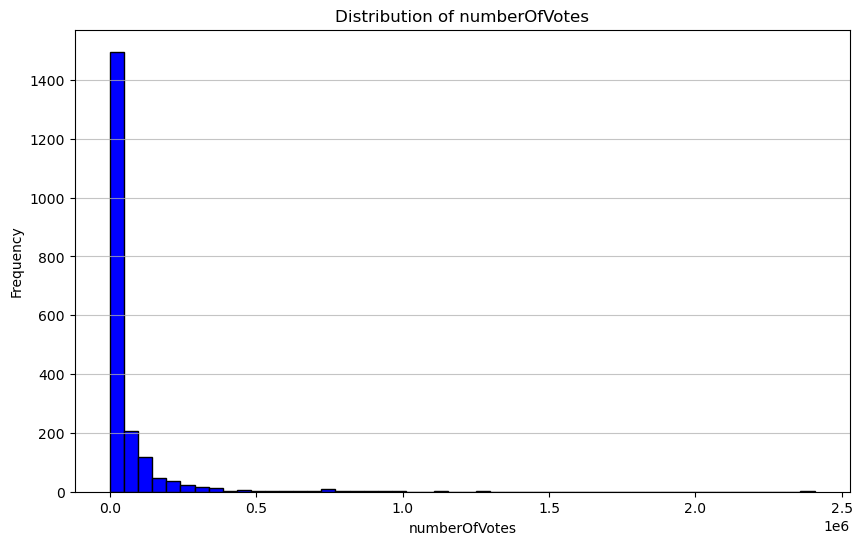

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['numberOfVotes'], bins=50, color='blue', edgecolor='black')
plt.title('Distribution of numberOfVotes')
plt.xlabel('numberOfVotes')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


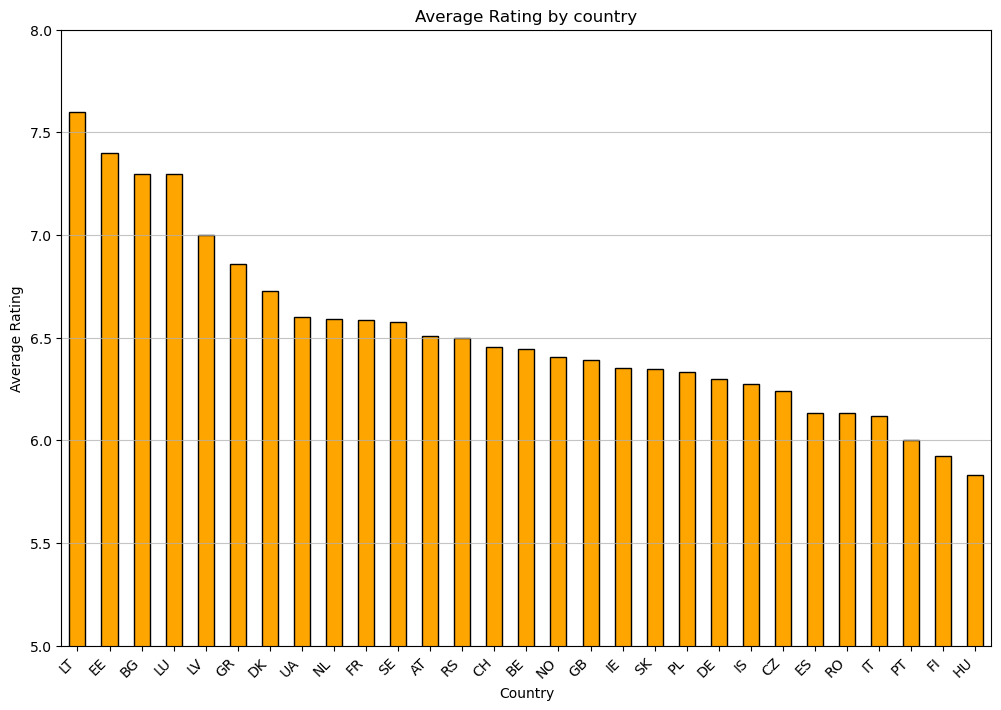

In [47]:
# Plot the average rating by genre
plt.figure(figsize=(12, 8))
df_genre = df.groupby('mainCountry')['imdbRating'].mean().sort_values(ascending=False)
df_genre.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Average Rating by country')
plt.xlabel('Country')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.ylim(5, 8)
plt.grid(axis='y', alpha=0.75)
plt.show()

T-statistic:  6.4266598906101455
P-value:  1.6892944891254477e-10


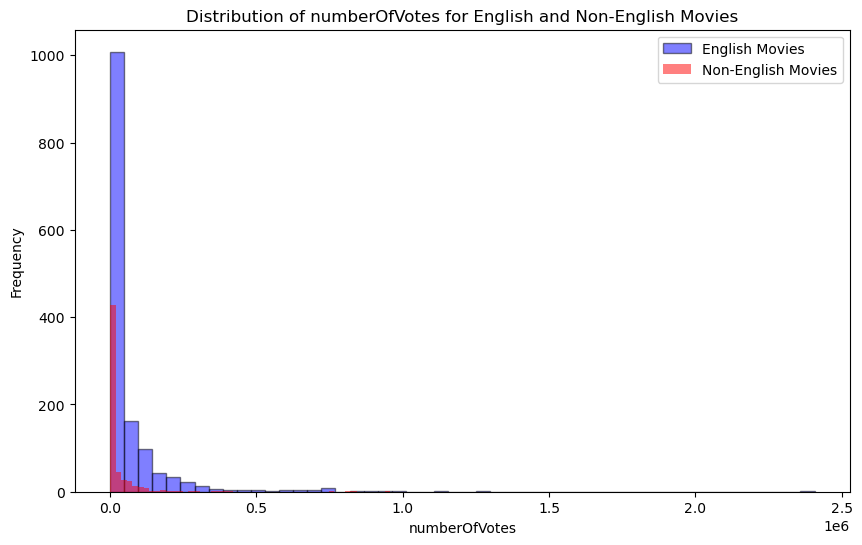

In [55]:
# P-value test for checking english speaking movies have more number of votes than non-english speaking movies
from scipy import stats
english_movies = df[df['firstLanguage'] == 'en']['numberOfVotes']
non_english_movies = df[df['firstLanguage'] != 'en']['numberOfVotes']
t_stat, p_value = stats.ttest_ind(english_movies, non_english_movies, equal_var=False)
print("T-statistic: ", t_stat)
print("P-value: ", p_value)

# plot the number og votes for english and non-english movies
plt.figure(figsize=(10, 6))
plt.hist(english_movies, bins=50, alpha=0.5, label='English Movies', color='blue', edgecolor='black')
plt.hist(non_english_movies, bins=50, alpha=0.5, label='Non-English Movies', color='red')
plt.title('Distribution of numberOfVotes for English and Non-English Movies')
plt.xlabel('numberOfVotes')
plt.ylabel('Frequency')
plt.legend()